## Car Price Prediction

In [3]:
import pandas as pd

# Load the dataset
df = pd.read_csv(r'C:\Users\sumit\DATA_SCIENCE\OASIS INTERNSHIP\car data.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
# Display concise summary of the DataFrame including data types and non-null values
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


None

In [5]:
# Check for missing values
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

Series([], dtype: int64)

In [6]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()

if duplicate_rows > 0:
    print(f"Found {duplicate_rows} duplicate rows. Removing them...")
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed successfully.")
else:
    print("No duplicate rows found.")

# Display the shape of the DataFrame after removing duplicates
print(f"DataFrame shape after handling duplicates: {df.shape}")

Found 2 duplicate rows. Removing them...
Duplicate rows removed successfully.
DataFrame shape after handling duplicates: (299, 9)


In [7]:
# Check unique values in 'Fuel_Type' column
print("Unique values in 'Fuel_Type' before cleaning:")
display(df['Fuel_Type'].value_counts())

Unique values in 'Fuel_Type' before cleaning:


Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

In [8]:
# Calculate 'Car_Age' from the 'Year' column
# Assuming the current year is 2024
df['Car_Age'] = 2024 - df['Year']

# Display the updated DataFrame with 'Car_Age'
display(df.head())

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,10
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,11
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,7
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,13
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,10


In [9]:
# Extract 'Brand' from 'Car_Name'
# Assuming the brand is the first word in 'Car_Name'
df['Brand'] = df['Car_Name'].apply(lambda x: x.split(' ')[0])

# Display the updated DataFrame with 'Brand'
display(df.head())

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Brand
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,10,ritz
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,11,sx4
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,7,ciaz
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,13,wagon
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,10,swift


In [10]:
# Check unique values in 'Brand' column
print("Unique values in 'Brand' after extraction:")
display(df['Brand'].value_counts())

Unique values in 'Brand' after extraction:


Brand
city        26
Bajaj       25
Royal       17
corolla     17
Honda       17
Hero        15
verna       14
etios       11
brio        10
fortuner    10
innova       9
ciaz         9
i20          9
Yamaha       8
TVS          8
grand        8
amaze        7
jazz         7
eon          6
alto         6
sx4          6
i10          5
ertiga       5
swift        5
ritz         4
KTM          4
wagon        4
dzire        4
Activa       3
creta        3
xcent        3
elantra      2
ignis        1
vitara       1
s            1
Mahindra     1
Hyosung      1
baleno       1
omni         1
Suzuki       1
camry        1
land         1
UM           1
800          1
Name: count, dtype: int64

In [11]:
# Define a mapping for inconsistent brand names to their standardized manufacturer names
brand_mapping = {
    'city': 'Honda',
    'Bajaj': 'Bajaj',
    'corolla': 'Toyota',
    'Royal': 'Royal Enfield',
    'Honda': 'Honda',
    'Hero': 'Hero',
    'verna': 'Hyundai',
    'etios': 'Toyota',
    'fortuner': 'Toyota',
    'brio': 'Honda',
    'ciaz': 'Maruti Suzuki',
    'innova': 'Toyota',
    'i20': 'Hyundai',
    'grand': 'Hyundai',
    'Yamaha': 'Yamaha',
    'TVS': 'TVS',
    'jazz': 'Honda',
    'amaze': 'Honda',
    'sx4': 'Maruti Suzuki',
    'eon': 'Hyundai',
    'alto': 'Maruti Suzuki',
    'swift': 'Maruti Suzuki',
    'i10': 'Hyundai',
    'ertiga': 'Maruti Suzuki',
    'dzire': 'Maruti Suzuki',
    'wagon': 'Maruti Suzuki',
    'ritz': 'Maruti Suzuki',
    'KTM': 'KTM',
    'creta': 'Hyundai',
    'xcent': 'Hyundai',
    'Activa': 'Honda',
    'elantra': 'Hyundai',
    '800': 'Maruti Suzuki',
    'ignis': 'Maruti Suzuki',
    'vitara': 'Maruti Suzuki',
    's': 'Maruti Suzuki',
    'Hyosung': 'Hyosung',
    'Mahindra': 'Mahindra',
    'UM': 'UM Lohia Two Wheelers',
    'land': 'Land Rover',
    'baleno': 'Maruti Suzuki',
    'omni': 'Maruti Suzuki',
    'camry': 'Toyota',
    'Suzuki': 'Maruti Suzuki'
}

# Apply the mapping to the 'Brand' column
df['Brand'] = df['Brand'].replace(brand_mapping)

print("Unique values in 'Brand' after cleaning:")
display(df['Brand'].value_counts())

Unique values in 'Brand' after cleaning:


Brand
Honda                    70
Maruti Suzuki            50
Hyundai                  50
Toyota                   48
Bajaj                    25
Royal Enfield            17
Hero                     15
Yamaha                    8
TVS                       8
KTM                       4
Land Rover                1
UM Lohia Two Wheelers     1
Hyosung                   1
Mahindra                  1
Name: count, dtype: int64

In [12]:
# Re-check unique values in 'Fuel_Type' column after previous steps
print("Unique values in 'Fuel_Type' before cleaning (re-check):")
display(df['Fuel_Type'].value_counts())

# Standardize 'Fuel_Type' to ensure consistency (e.g., 'Petrol' vs 'petrol')
# Convert to lowercase and then capitalize the first letter
df['Fuel_Type'] = df['Fuel_Type'].str.capitalize()

print("Unique values in 'Fuel_Type' after cleaning:")
display(df['Fuel_Type'].value_counts())

Unique values in 'Fuel_Type' before cleaning (re-check):


Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

Unique values in 'Fuel_Type' after cleaning:


Fuel_Type
Petrol    239
Diesel     58
Cng         2
Name: count, dtype: int64

In [13]:
# Define a mapping for inconsistent brand names to their standardized manufacturer names
brand_mapping = {
    'city': 'Honda',
    'Bajaj': 'Bajaj',
    'corolla': 'Toyota',
    'Royal': 'Royal Enfield',
    'Honda': 'Honda',
    'Hero': 'Hero',
    'verna': 'Hyundai',
    'etios': 'Toyota',
    'fortuner': 'Toyota',
    'brio': 'Honda',
    'ciaz': 'Maruti Suzuki',
    'innova': 'Toyota',
    'i20': 'Hyundai',
    'grand': 'Hyundai',
    'Yamaha': 'Yamaha',
    'TVS': 'TVS',
    'jazz': 'Honda',
    'amaze': 'Honda',
    'sx4': 'Maruti Suzuki',
    'eon': 'Hyundai',
    'alto': 'Maruti Suzuki',
    'swift': 'Maruti Suzuki',
    'i10': 'Hyundai',
    'ertiga': 'Maruti Suzuki',
    'dzire': 'Maruti Suzuki',
    'wagon': 'Maruti Suzuki',
    'ritz': 'Maruti Suzuki',
    'KTM': 'KTM',
    'creta': 'Hyundai',
    'xcent': 'Hyundai',
    'Activa': 'Honda',
    'elantra': 'Hyundai',
    '800': 'Maruti Suzuki',
    'ignis': 'Maruti Suzuki',
    'vitara': 'Maruti Suzuki',
    's': 'Maruti Suzuki',
    'Hyosung': 'Hyosung',
    'Mahindra': 'Mahindra',
    'UM': 'UM Lohia Two Wheelers',
    'land': 'Land Rover',
    'baleno': 'Maruti Suzuki',
    'omni': 'Maruti Suzuki',
    'camry': 'Toyota',
    'Suzuki': 'Maruti Suzuki'
}

# Apply the mapping to the 'Brand' column
df['Brand'] = df['Brand'].replace(brand_mapping)

print("Unique values in 'Brand' after cleaning:")
display(df['Brand'].value_counts())

Unique values in 'Brand' after cleaning:


Brand
Honda                    70
Maruti Suzuki            50
Hyundai                  50
Toyota                   48
Bajaj                    25
Royal Enfield            17
Hero                     15
Yamaha                    8
TVS                       8
KTM                       4
Land Rover                1
UM Lohia Two Wheelers     1
Hyosung                   1
Mahindra                  1
Name: count, dtype: int64

In [14]:
# Re-check unique values in 'Fuel_Type' column after previous steps
print("Unique values in 'Fuel_Type' before cleaning (re-check):")
display(df['Fuel_Type'].value_counts())

# Standardize 'Fuel_Type' to ensure consistency (e.g., 'Petrol' vs 'petrol')
# Convert to lowercase and then capitalize the first letter
df['Fuel_Type'] = df['Fuel_Type'].str.capitalize()

print("Unique values in 'Fuel_Type' after cleaning:")
display(df['Fuel_Type'].value_counts())

Unique values in 'Fuel_Type' before cleaning (re-check):


Fuel_Type
Petrol    239
Diesel     58
Cng         2
Name: count, dtype: int64

Unique values in 'Fuel_Type' after cleaning:


Fuel_Type
Petrol    239
Diesel     58
Cng         2
Name: count, dtype: int64

In [15]:
display(df.head())

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Brand
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,10,Maruti Suzuki
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,11,Maruti Suzuki
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,7,Maruti Suzuki
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,13,Maruti Suzuki
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,10,Maruti Suzuki


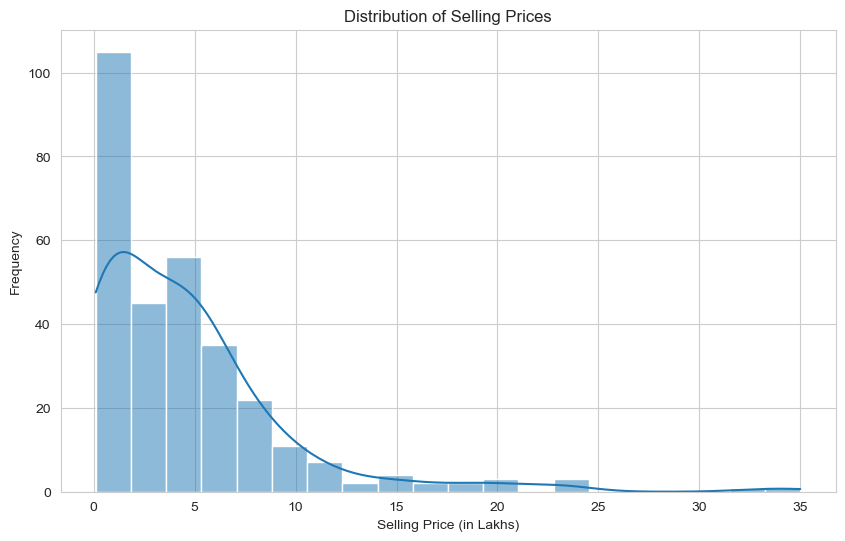

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(df['Selling_Price'], kde=True, bins=20)
plt.title('Distribution of Selling Prices')
plt.xlabel('Selling Price (in Lakhs)')
plt.ylabel('Frequency')
plt.show()

C:\Users\sumit\AppData\Local\Temp\ipykernel_4904\4139486854.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df, palette='viridis')


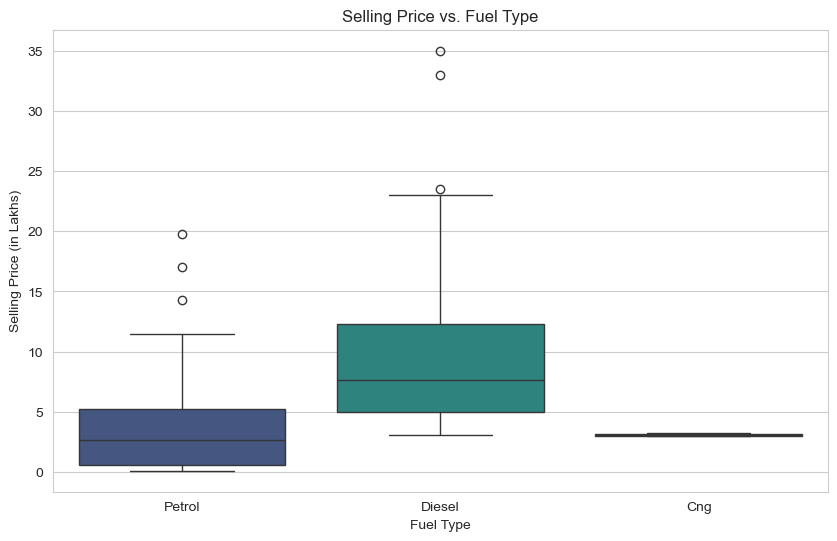

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df, palette='viridis')
plt.title('Selling Price vs. Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price (in Lakhs)')
plt.show()

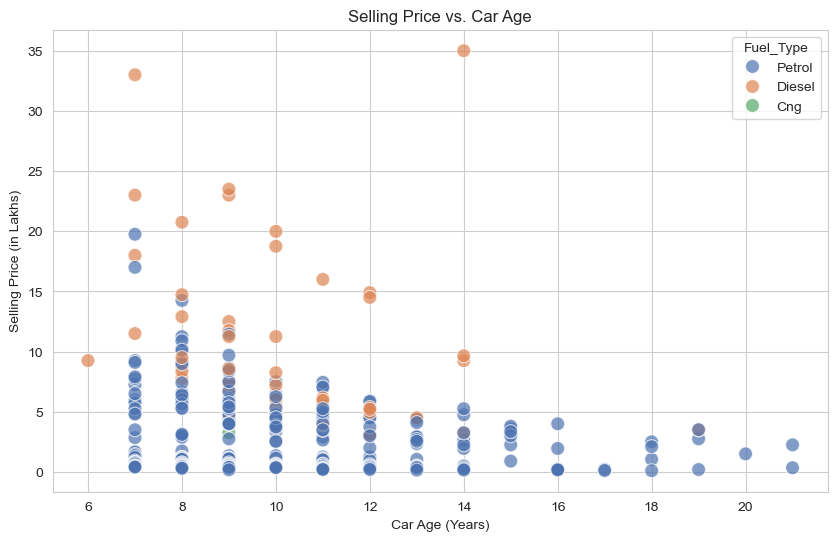

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Car_Age', y='Selling_Price', data=df, hue='Fuel_Type', palette='deep', s=100, alpha=0.7)
plt.title('Selling Price vs. Car Age')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price (in Lakhs)')
plt.grid(True)
plt.show()

In [19]:
# Identify categorical columns (object type)
categorical_cols = df.select_dtypes(include='object').columns

print("Categorical columns identified:", categorical_cols.tolist())

# Display unique values for each categorical column before encoding
for col in categorical_cols:
    print(f"\nUnique values in '{col}':")
    display(df[col].value_counts())

Categorical columns identified: ['Car_Name', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Brand']

Unique values in 'Car_Name':


Car_Name
city                        26
corolla altis               16
verna                       14
brio                        10
fortuner                    10
                            ..
Honda CB Trigger             1
Yamaha FZ S                  1
Bajaj Pulsar 135 LS          1
Activa 4g                    1
Bajaj Avenger Street 220     1
Name: count, Length: 98, dtype: int64


Unique values in 'Fuel_Type':


Fuel_Type
Petrol    239
Diesel     58
Cng         2
Name: count, dtype: int64


Unique values in 'Seller_Type':


Seller_Type
Dealer        193
Individual    106
Name: count, dtype: int64


Unique values in 'Transmission':


Transmission
Manual       260
Automatic     39
Name: count, dtype: int64


Unique values in 'Brand':


Brand
Honda                    70
Maruti Suzuki            50
Hyundai                  50
Toyota                   48
Bajaj                    25
Royal Enfield            17
Hero                     15
Yamaha                    8
TVS                       8
KTM                       4
Land Rover                1
UM Lohia Two Wheelers     1
Hyosung                   1
Mahindra                  1
Name: count, dtype: int64

In [20]:
# Apply One-Hot Encoding to the identified categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("DataFrame after One-Hot Encoding:")
display(df_encoded.head())

DataFrame after One-Hot Encoding:


,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Car_Name_Activa 3g,Car_Name_Activa 4g,Car_Name_Bajaj ct 100,Car_Name_Bajaj Avenger 150,...,Brand_Hyundai,Brand_KTM,Brand_Land Rover,Brand_Mahindra,Brand_Maruti Suzuki,Brand_Royal Enfield,Brand_TVS,Brand_Toyota,Brand_UM Lohia Two Wheelers,Brand_Yamaha
0,2014,3.35,5.59,27000,0,10,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
1,2013,4.75,9.54,43000,0,11,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,2017,7.25,9.85,6900,0,7,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,2011,2.85,4.15,5200,0,13,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,2014,4.60,6.87,42450,0,10,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False


In [21]:
# Display the info of the new encoded DataFrame to see the new columns and data types
display(df_encoded.info())

<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 300
Columns: 120 entries, Year to Brand_Yamaha
dtypes: bool(114), float64(2), int64(4)
memory usage: 49.6 KB


None

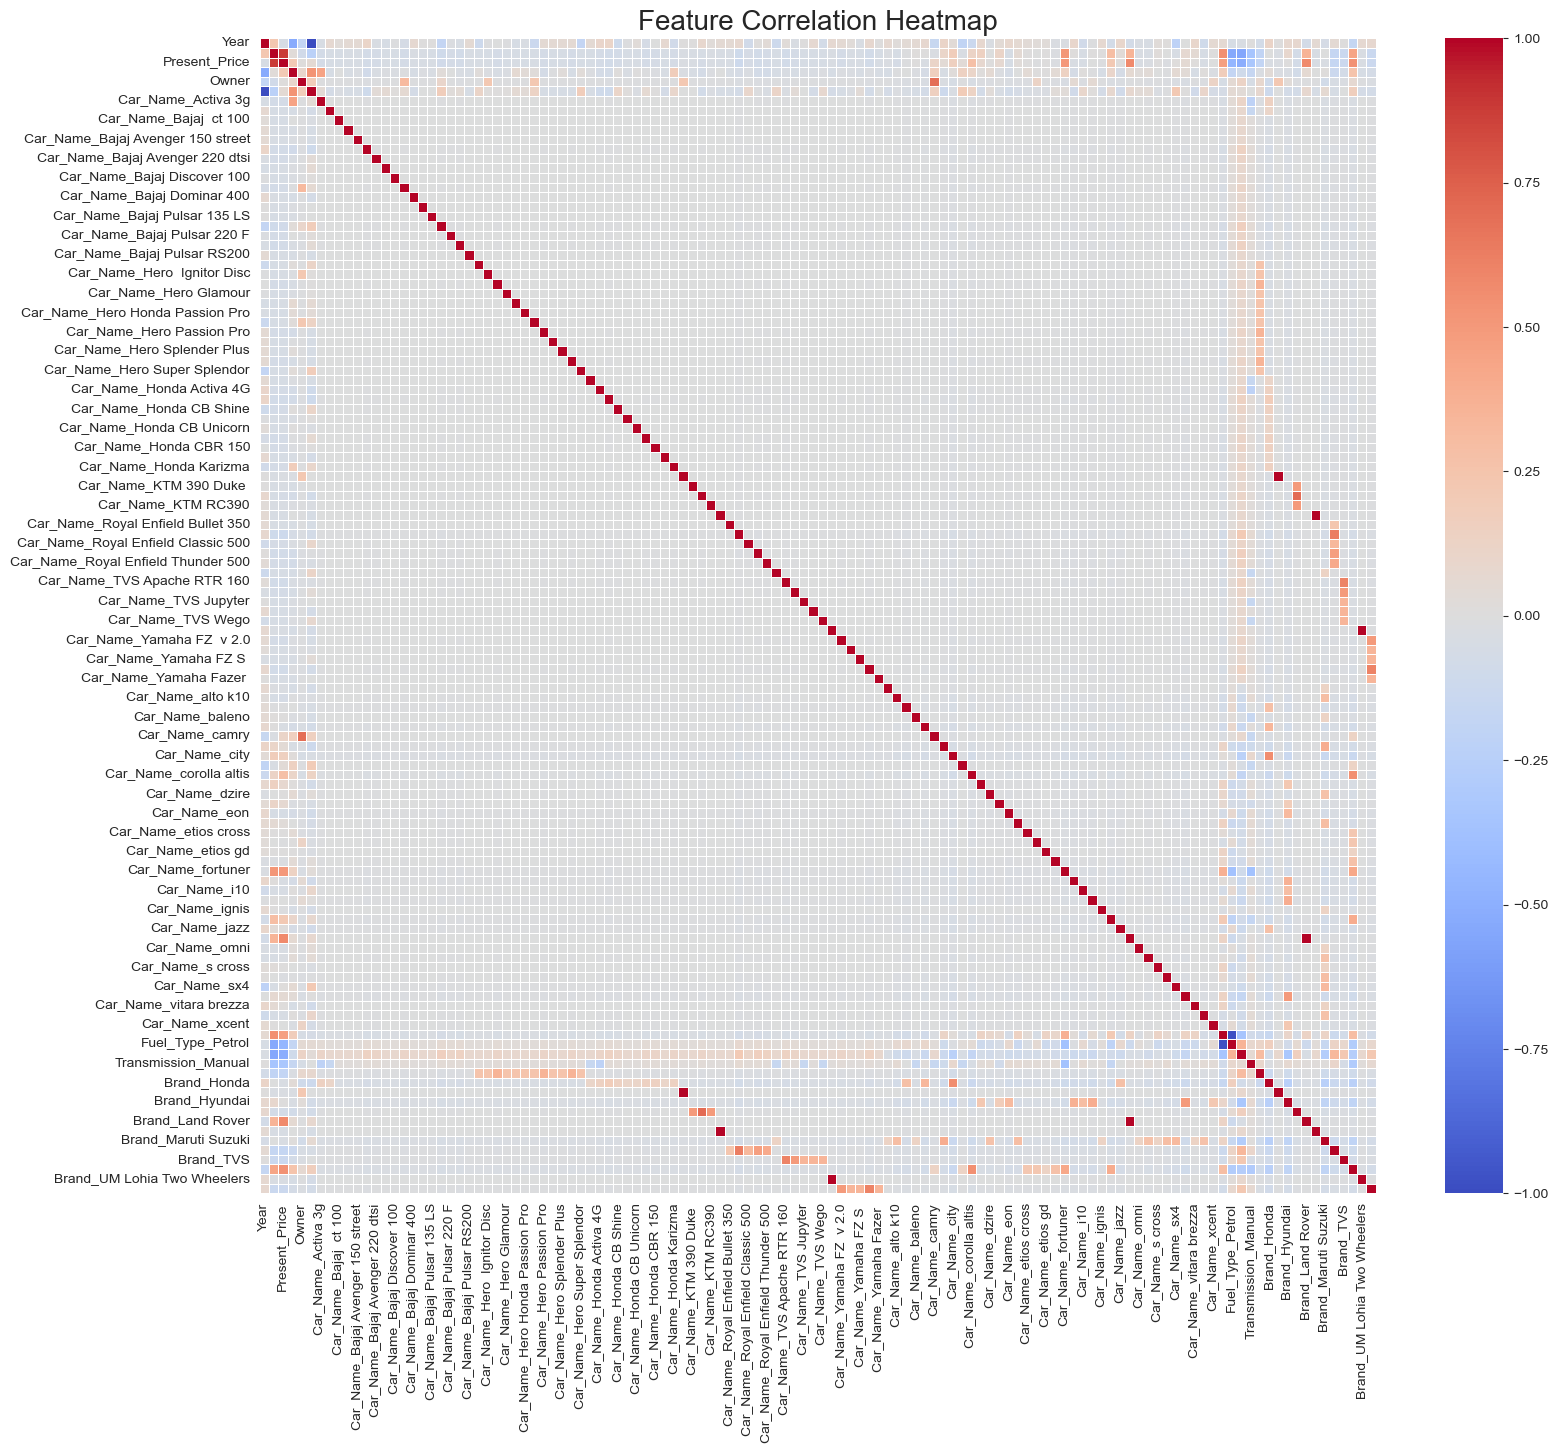

In [24]:
# Calculate the correlation matrix for the encoded DataFrame
correlation_matrix = df_encoded.corr()

# Plotting the heatmap
plt.figure(figsize=(18, 15)) # Adjust figure size for better readability
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Feature Correlation Heatmap', fontsize=20)
plt.show()

In [22]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_encoded.drop('Selling_Price', axis=1)
y = df_encoded['Selling_Price']

# Split the data into training and testing sets
# We'll use a test size of 20% and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (239, 119)
Shape of X_test: (60, 119)
Shape of y_train: (239,)
Shape of y_test: (60,)


In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize and train the Linear Regression model
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = linear_reg_model.predict(X_test)

# Evaluate the model
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = mse_lr**0.5 # Calculate Root Mean Squared Error
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Model Evaluation:")
print(f"  Mean Absolute Error (MAE): {mae_lr:.2f}")
print(f"  Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_lr:.2f}")
print(f"  R-squared (R2): {r2_lr:.2f}")

Linear Regression Model Evaluation:
  Mean Absolute Error (MAE): 1.61
  Mean Squared Error (MSE): 8.26
  Root Mean Squared Error (RMSE): 2.87
  R-squared (R2): 0.68


In [24]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
# Using a random state for reproducibility
random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = random_forest_model.predict(X_test)

# Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mse_rf**0.5
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Model Evaluation:")
print(f"  Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"  Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"  R-squared (R2): {r2_rf:.2f}")

Random Forest Regressor Model Evaluation:
  Mean Absolute Error (MAE): 1.32
  Mean Squared Error (MSE): 10.22
  Root Mean Squared Error (RMSE): 3.20
  R-squared (R2): 0.60


In [25]:
from sklearn.ensemble import GradientBoostingRegressor

# Initialize and train the Gradient Boosting Regressor model
# Using a random state for reproducibility
gradient_boosting_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gradient_boosting_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_gb = gradient_boosting_model.predict(X_test)

# Evaluate the model
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = mse_gb**0.5
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Regressor Model Evaluation:")
print(f"  Mean Absolute Error (MAE): {mae_gb:.2f}")
print(f"  Mean Squared Error (MSE): {mse_gb:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_gb:.2f}")
print(f"  R-squared (R2): {r2_gb:.2f}")

Gradient Boosting Regressor Model Evaluation:
  Mean Absolute Error (MAE): 1.22
  Mean Squared Error (MSE): 8.76
  Root Mean Squared Error (RMSE): 2.96
  R-squared (R2): 0.66


In [26]:
# Create a dictionary to store the evaluation results
evaluation_results = {
    'Model': ['Linear Regression', 'Random Forest Regressor', 'Gradient Boosting Regressor'],
    'MAE': [mae_lr, mae_rf, mae_gb],
    'RMSE': [rmse_lr, rmse_rf, rmse_gb],
    'R2 Score': [r2_lr, r2_rf, r2_gb]
}

# Create a DataFrame from the results
evaluation_df = pd.DataFrame(evaluation_results)

# Display the evaluation DataFrame, sorted by R2 score in descending order
display(evaluation_df.sort_values(by='R2 Score', ascending=False))

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.613023,2.873854,0.679550
2,Gradient Boosting Regressor,1.219246,2.960210,0.660003
1,Random Forest Regressor,1.319188,3.196495,0.603559


C:\Users\sumit\AppData\Local\Temp\ipykernel_4964\4146985681.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')


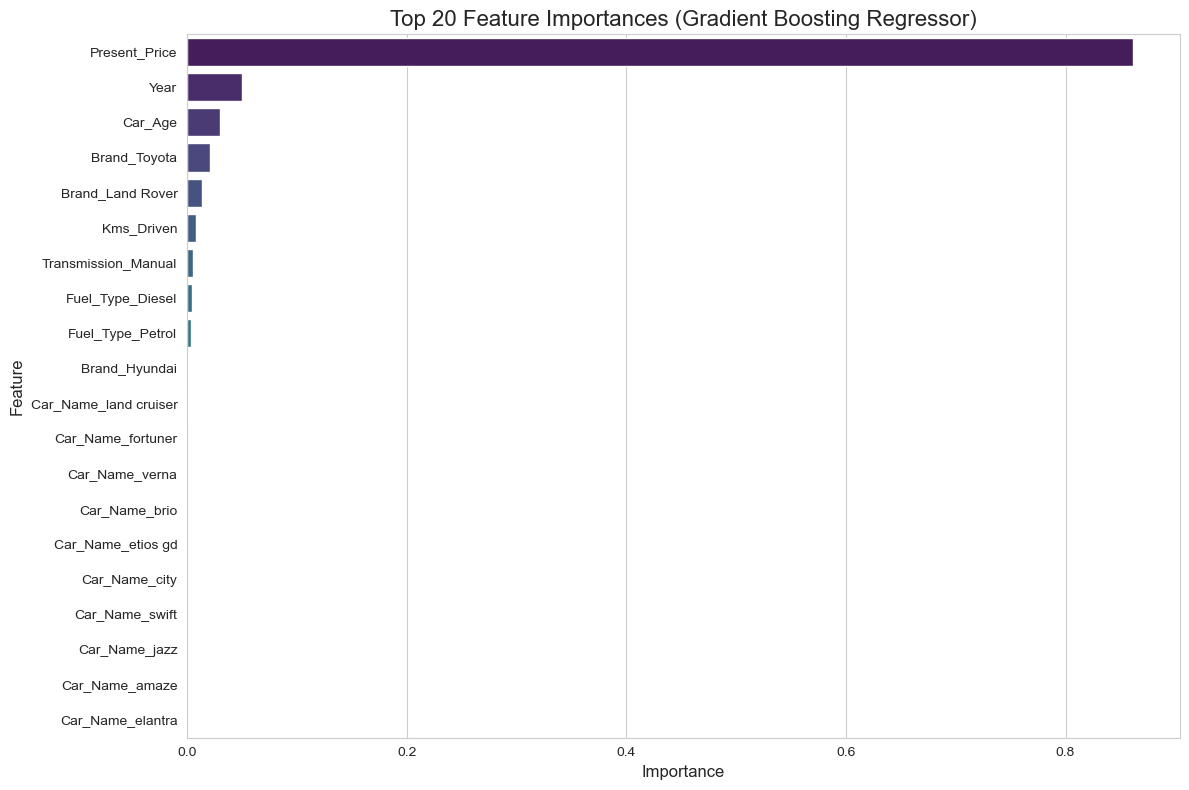

In [27]:
# Get feature importances from the Gradient Boosting model
feature_importances = gradient_boosting_model.feature_importances_

# Get feature names from X (training data without the target variable)
feature_names = X.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Select the top N features (e.g., top 20) for better readability
top_n = 20
top_features = importance_df.head(top_n)

# Plot the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')
plt.title(f'Top {top_n} Feature Importances (Gradient Boosting Regressor)', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()